In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your saved data
edges = gpd.read_file("/home/jovyan/work/data/london_streets.gpkg")
buildings = gpd.read_file("/home/jovyan/work/data/london_buildings.gpkg")
pois = gpd.read_file("/home/jovyan/work/data/london_pois.gpkg")

print(f"Streets: {len(edges)}")
print(f"Buildings: {len(buildings)}")
print(f"POIs: {len(pois)}")
print("All data loaded.")

Streets: 1382
Buildings: 2104
POIs: 3388
All data loaded.


In [3]:
# Convert all three datasets to metres-based coordinate system
edges_proj = edges.to_crs(epsg=27700)
buildings_proj = buildings.to_crs(epsg=27700)
pois_proj = pois.to_crs(epsg=27700)

print("Projected to British National Grid (metres)")
print(f"Example segment length in metres: {edges_proj.geometry.length.mean():.1f}m")

Projected to British National Grid (metres)
Example segment length in metres: 59.7m


In [4]:
# Calculate segment length in metres
edges_proj['length_m'] = edges_proj.geometry.length

print(f"Shortest segment: {edges_proj['length_m'].min():.1f}m")
print(f"Longest segment: {edges_proj['length_m'].max():.1f}m")
print(f"Average length: {edges_proj['length_m'].mean():.1f}m")

Shortest segment: 1.1m
Longest segment: 447.2m
Average length: 59.7m


In [5]:
# Create a 50 metre buffer around each street segment
edges_buffered = edges_proj.copy()
edges_buffered['geometry'] = edges_proj.geometry.buffer(50)

# Count how many POIs fall inside each buffer
joined_pois = gpd.sjoin(edges_buffered[['geometry']], 
                         pois_proj[['geometry']], 
                         how='left', 
                         predicate='intersects')

poi_counts = joined_pois.groupby(joined_pois.index).size()
edges_proj['poi_count_50m'] = poi_counts.reindex(edges_proj.index, fill_value=0)

print(f"Average POIs within 50m: {edges_proj['poi_count_50m'].mean():.1f}")
print(f"Max POIs within 50m: {edges_proj['poi_count_50m'].max()}")
print(f"Segments with zero POIs: {(edges_proj['poi_count_50m']==0).sum()}")

Average POIs within 50m: 17.9
Max POIs within 50m: 103
Segments with zero POIs: 0


What these numbers are telling you
Segment lengths:

Shortest is 1.1 metres — that is basically a tiny connector segment, almost like a junction. You will want to filter these out later as they are noise.
Longest is 447 metres — that is a long arterial road.
Average 59.7 metres — dense historic city, short blocks. Makes sense.

POI counts:

Average of 17.9 POI within 50 metres of every street — the City of London is extremely dense with amenities. This makes sense — it is one of the most commercially active square miles in the world.
Maximum of 103 POI within 50 metres of one segment — that street is surrounded by shops, cafes, restaurants. Almost certainly somewhere like Leadenhall Market or around Bank station.
Zero segments with zero POI — every single street in the City of London has at least one amenity within 50 metres. That tells you something important about this area specifically.

This last point is actually worth noting in your dissertation. It means POI count alone may not differentiate street types well within the City of London — because every street scores reasonably high. When you expand to Greater London you will see much more variation. This is a good critical observation to make.

In [6]:
# Count buildings within 50m of each segment
joined_buildings = gpd.sjoin(edges_buffered[['geometry']], 
                              buildings_proj[['geometry']], 
                              how='left', 
                              predicate='intersects')

building_counts = joined_buildings.groupby(joined_buildings.index).size()
edges_proj['building_count_50m'] = building_counts.reindex(edges_proj.index, fill_value=0)

print(f"Average buildings within 50m: {edges_proj['building_count_50m'].mean():.1f}")
print(f"Max buildings within 50m: {edges_proj['building_count_50m'].max()}")
print(f"Min buildings within 50m: {edges_proj['building_count_50m'].min()}")

Average buildings within 50m: 16.2
Max buildings within 50m: 72
Min buildings within 50m: 1


In [7]:
# Look at what road types you have
print("Road types in your data:")
print(edges_proj['highway'].value_counts())

Road types in your data:
highway
unclassified                        449
residential                         310
tertiary                            308
primary                             262
secondary                            25
primary_link                         10
['residential', 'unclassified']       6
trunk                                 4
living_street                         3
['residential', 'living_street']      2
['unclassified', 'tertiary']          1
tertiary_link                         1
secondary_link                        1
Name: count, dtype: int64


What the building counts mean

Average of 16.2 buildings within 50 metres of every segment — very dense built environment as expected
Maximum of 72 buildings within 50 metres of one segment — that street is surrounded by lots of small buildings, likely in a historic dense area
Minimum of 1 — every street has at least one building nearby, nobody is isolated

What the road types are telling you
This is already a primitive typology before you even run any machine learning. Look at what you have:
Road typeCountWhat it meansunclassified449Minor local streets with no specific classificationresidential310Streets primarily serving housingtertiary308Local roads connecting to larger roadsprimary262Major roads — think Holborn, London Wallsecondary25Important but not primary roadstrunk4Near-motorway level roadsliving_street3Pedestrian priority streets
The messy ones like ['residential', 'unclassified'] are streets that OSM volunteers tagged with two types. You need to clean those. We will do that now

In [8]:
# Clean highway column - take first value if it's a list
def clean_highway(val):
    if isinstance(val, list):
        return val[0]
    return val

edges_proj['highway_clean'] = edges_proj['highway'].apply(clean_highway)

# Convert road types to numbers for machine learning
highway_map = {
    'trunk': 6,
    'primary': 5,
    'primary_link': 5,
    'secondary': 4,
    'secondary_link': 4,
    'tertiary': 3,
    'tertiary_link': 3,
    'residential': 2,
    'living_street': 2,
    'unclassified': 1
}

edges_proj['highway_rank'] = edges_proj['highway_clean'].map(highway_map).fillna(1)

print("Road type distribution after cleaning:")
print(edges_proj['highway_rank'].value_counts().sort_index(ascending=False))

Road type distribution after cleaning:
highway_rank
6.0      4
5.0    272
4.0     26
3.0    309
2.0    313
1.0    458
Name: count, dtype: int64


In [9]:
import osmnx as ox
import networkx as nx

# Reload the graph to calculate connectivity
G = ox.graph_from_file = ox.graph_from_place("City of London, UK", 
                                               network_type="drive")

# Get degree of each node (how many streets connect there)
degree_dict = dict(G.degree())

# For each edge get the average degree of its two end nodes
edges_proj_reset = edges_proj.reset_index()
edges_proj_reset['degree_u'] = edges_proj_reset['u'].map(degree_dict)
edges_proj_reset['degree_v'] = edges_proj_reset['v'].map(degree_dict)
edges_proj_reset['avg_connectivity'] = (edges_proj_reset['degree_u'] + 
                                         edges_proj_reset['degree_v']) / 2

edges_proj = edges_proj_reset.set_index(['u','v','key'])

print(f"Average connectivity: {edges_proj['avg_connectivity'].mean():.2f}")
print(f"Max connectivity: {edges_proj['avg_connectivity'].max():.0f}")
print(f"Min connectivity: {edges_proj['avg_connectivity'].min():.0f}")

Average connectivity: 4.62
Max connectivity: 8
Min connectivity: 2


What connectivity is telling you

Average of 4.62 — on average each street segment connects to about 5 other streets at its ends. That is a well connected urban grid which makes sense for the City of London.
Maximum of 8 — some intersections are major junctions where many streets meet. Think Bank junction — one of the busiest and most connected points in the City.
Minimum of 2 — every segment connects to at least 2 others. No dead ends in your drive network which makes sense since osmnx drive mode excludes cul-de-sacs.


What your road rank distribution means
You now have a clear hierarchy of streets in your data:

458 minor unclassified streets — the small alleys and unnamed lanes
313 residential and living streets — quieter local roads
309 tertiary roads — local connectors
272 primary roads — the major arteries like London Wall, Holborn
Only 4 trunk roads — the near-motorway level roads at the edges

This distribution already hints at your typologies before clustering even starts.

In [10]:
# Build your master feature table
features = edges_proj[[
    'length_m',
    'poi_count_50m', 
    'building_count_50m',
    'highway_rank',
    'avg_connectivity'
]].copy()

# Check for any missing values
print("Missing values per feature:")
print(features.isnull().sum())
print(f"\nTotal segments: {len(features)}")
print("\nFirst 5 rows of your feature table:")
print(features.head())

Missing values per feature:
length_m              0
poi_count_50m         0
building_count_50m    0
highway_rank          0
avg_connectivity      0
dtype: int64

Total segments: 1382

First 5 rows of your feature table:
                         length_m  poi_count_50m  building_count_50m  \
u      v          key                                                  
104318 7946372941 0      3.674630             12                   9   
       1360122917 0    107.862305             25                  17   
       25509527   0     24.884122             12                   9   
104321 24951853   0     19.876618             58                  16   
       24951854   0     54.073354             51                  18   

                       highway_rank  avg_connectivity  
u      v          key                                  
104318 7946372941 0             5.0               6.0  
       1360122917 0             5.0               6.0  
       25509527   0             1.0               6

In [11]:
# Reset index and save
features_save = features.reset_index()
features_save.to_csv("/home/jovyan/work/data/london_features.csv", index=False)
print("Feature table saved to data folder.")
print(f"Shape: {features_save.shape}")
print("\nYour dissertation feature table:")
print(features_save.describe().round(2))

Feature table saved to data folder.
Shape: (1382, 8)

Your dissertation feature table:
                  u             v      key  length_m  poi_count_50m  \
count  1.382000e+03  1.382000e+03  1382.00   1382.00        1382.00   
mean   2.042897e+09  2.054795e+09     0.00     59.71          17.86   
std    3.121736e+09  3.128741e+09     0.05     50.99          12.91   
min    1.043180e+05  1.043180e+05     0.00      1.12           1.00   
25%    2.525237e+07  2.524812e+07     0.00     25.35           9.00   
50%    3.554169e+08  3.612595e+08     0.00     47.88          15.00   
75%    2.387194e+09  2.387194e+09     0.00     78.96          24.00   
max    1.366770e+10  1.366770e+10     1.00    447.15         103.00   

       building_count_50m  highway_rank  avg_connectivity  
count             1382.00       1382.00           1382.00  
mean                16.17          2.53              4.62  
std                  9.78          1.47              1.13  
min                  1.00        

This is what you write in your Chapter 3:
Length — segments range from 1.1m to 447m with an average of 59.7m. The short segments at the lower end may represent connector pieces at complex junctions and could be filtered in future analysis.
POI count — ranges from 1 to 103 with an average of 17.9. High variation with a standard deviation of 12.9 suggests meaningful differences in commercial activity across streets.
Building count — ranges from 1 to 72 with an average of 16.2. Again high variation suggesting density differences across the study area.
Highway rank — mean of 2.53 with most streets clustering around rank 1 to 3, confirming the City of London's predominantly local street character with a smaller proportion of primary arterials.
Connectivity — ranges from 2 to 8 with an average of 4.62 and relatively low standard deviation of 1.13, suggesting a consistently well connected grid.

Now we normalise and cluster
Before clustering you must normalise your features. Right now length is in metres going up to 447, while highway rank only goes from 1 to 6. If you cluster on raw numbers the algorithm will be dominated by length just because it has bigger numbers. Normalising puts everything on the same scale.

In [12]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Select just the five feature columns
feature_cols = ['length_m', 'poi_count_50m', 'building_count_50m', 
                'highway_rank', 'avg_connectivity']

X = features[feature_cols].values

# Normalise — every feature gets mean 0 and standard deviation 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before normalisation — length_m range:")
print(f"  Min: {features['length_m'].min():.1f}, Max: {features['length_m'].max():.1f}")

print("\nAfter normalisation — length_m range:")
print(f"  Min: {X_scaled[:,0].min():.2f}, Max: {X_scaled[:,0].max():.2f}")

print("\nAll features now on the same scale. Ready for clustering.")

Before normalisation — length_m range:
  Min: 1.1, Max: 447.2

After normalisation — length_m range:
  Min: -1.15, Max: 7.60

All features now on the same scale. Ready for clustering.


Everything is on the same scale now. Notice how length went from a range of 1 to 447 down to -1.15 to 7.60. Every feature is now comparable. The algorithm will treat them all equally.


finding your typologies
Before running K-means you need to decide how many clusters — how many street types — to look for. You do not just guess. You use something called the elbow method which tests different numbers of clusters and shows you where adding more stops being useful.

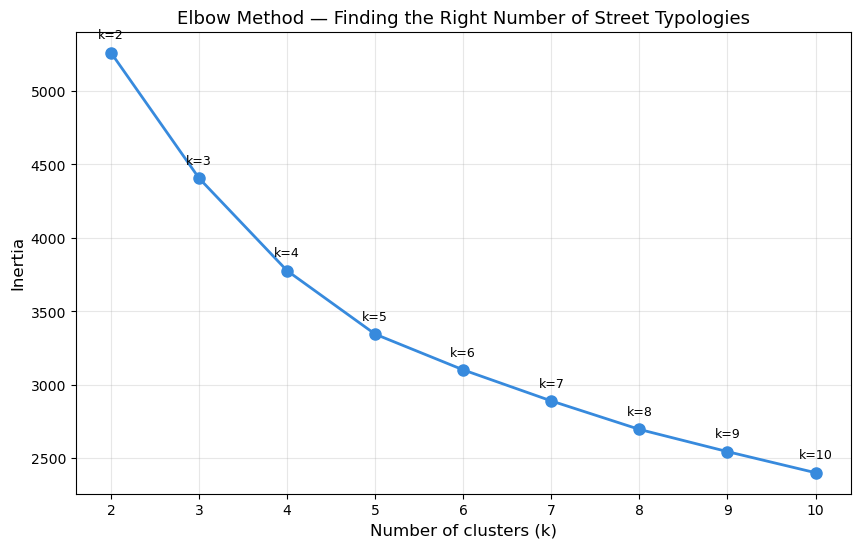

Elbow curve saved.


In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Test clustering with 2 to 10 clusters
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_range, inertia, 'o-', color='#378ADD', linewidth=2, markersize=8)
ax.set_xlabel('Number of clusters (k)', fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)
ax.set_title('Elbow Method — Finding the Right Number of Street Typologies', fontsize=13)
ax.grid(True, alpha=0.3)

# Mark each point
for k, val in zip(k_range, inertia):
    ax.annotate(f'k={k}', (k, val), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9)

plt.savefig("/home/jovyan/work/outputs/elbow_curve.png", 
            dpi=150, bbox_inches="tight")
plt.show()
print("Elbow curve saved.")

Your elbow is at k=5
The curve noticeably changes gradient between k=4 and k=5, and from k=5 onwards it becomes much flatter. This means 5 clusters is your optimal number of street typologies.
This is also academically sensible. Five street types is interpretable and meaningful — enough variety to be interesting, not so many that they become confusing.

In [14]:
# Run K-means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
features['cluster'] = kmeans.fit_predict(X_scaled)

# See how many streets in each cluster
print("Street segments per cluster:")
print(features['cluster'].value_counts().sort_index())

Street segments per cluster:
cluster
0    240
1    181
2     93
3    490
4    378
Name: count, dtype: int64


In [15]:
# What are the average feature values per cluster
cluster_profiles = features.groupby('cluster')[feature_cols].mean().round(2)
print("Average feature values per cluster:")
print(cluster_profiles)

Average feature values per cluster:
         length_m  poi_count_50m  building_count_50m  highway_rank  \
cluster                                                              
0           43.77          14.95               10.63          4.93   
1           76.00          38.20               32.13          2.42   
2          194.40          25.82               21.37          3.01   
3           41.70          12.54               12.57          1.66   
4           52.22          14.90               15.44          2.08   

         avg_connectivity  
cluster                    
0                    4.19  
1                    4.94  
2                    4.40  
3                    3.84  
4                    5.79  


What your 5 clusters actually areLook at each cluster's feature profile and what it tells you:Cluster 0 — 240 streets
High highway rank (4.93 — near primary), short segments (43m), moderate POI, low buildings. These are your major arterial roads — primary and secondary roads that are important for movement but not the most active at street level. Think Upper Thames Street, London Wall.Cluster 1 — 181 streets
Highest POI by far (38.2), highest buildings (32.1), moderate highway rank, long segments (76m). These are your active commercial streets — the busiest, most densely lined streets with the most shops and amenities. Think Cheapside, Leadenhall Street, Fleet Street.Cluster 2 — 93 streets
By far the longest segments (194m), moderate POI, moderate buildings, moderate rank. These are your long connector roads — longer stretches that link areas together. Think the bigger through-roads at the edges of the City.Cluster 3 — 490 streets — your largest group
Shortest segments (41m), lowest POI (12.5), lowest highway rank (1.66), lowest connectivity (3.84). These are your quiet back lanes and minor streets — the small unnamed alleys and local streets that make up the bulk of the historic City street network.

Cluster 4 — 378 streets
Highest connectivity of all (5.79), short segments, low POI, low rank. These are your well connected local streets — streets that sit at busy junctions and connect many other streets but are not major roads themselves.

In [16]:
# Name your typologies
cluster_names = {
    0: 'Arterial Road',
    1: 'Active Commercial Street',
    2: 'Long Connector Road',
    3: 'Quiet Back Lane',
    4: 'Connected Local Street'
}

features['typology'] = features['cluster'].map(cluster_names)

print("Your street typologies:")
print(features['typology'].value_counts())

Your street typologies:
typology
Quiet Back Lane             490
Connected Local Street      378
Arterial Road               240
Active Commercial Street    181
Long Connector Road          93
Name: count, dtype: int64


In [17]:
features_save = features.reset_index()
features_save.to_csv("/home/jovyan/work/data/london_clustered.csv", index=False)
print("Clustered data saved.")

Clustered data saved.


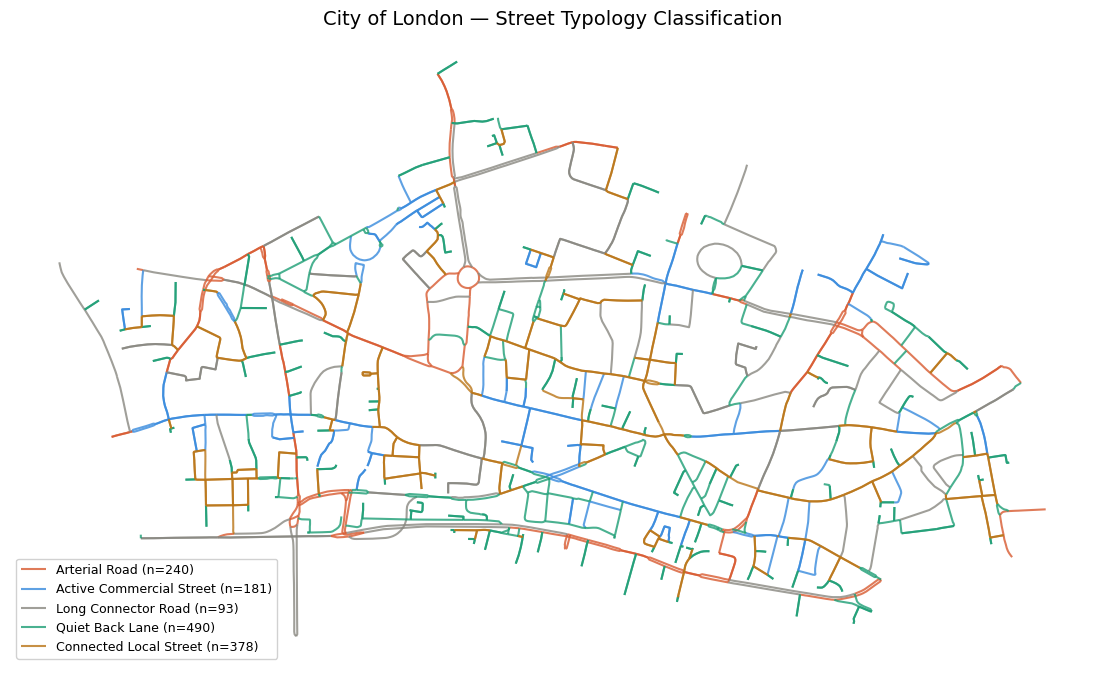

Typology map saved.


In [18]:
# Merge typology labels back onto your projected edges
edges_typed = edges_proj.copy().reset_index()
features_reset = features.reset_index()
edges_typed = edges_typed.merge(
    features_reset[['u','v','key','typology']], 
    on=['u','v','key'], 
    how='left'
)

# Colour each typology
colour_map = {
    'Arterial Road': '#D85A30',
    'Active Commercial Street': '#378ADD',
    'Long Connector Road': '#888780',
    'Quiet Back Lane': '#1D9E75',
    'Connected Local Street': '#BA7517'
}

fig, ax = plt.subplots(figsize=(14, 10))

for typology, colour in colour_map.items():
    subset = edges_typed[edges_typed['typology'] == typology]
    subset.plot(ax=ax, color=colour, linewidth=1.5, 
                label=f'{typology} (n={len(subset)})', alpha=0.8)

ax.set_title("City of London — Street Typology Classification", fontsize=14)
ax.set_axis_off()
ax.legend(loc='lower left', fontsize=9, framealpha=0.9)

plt.savefig("/home/jovyan/work/outputs/london_typology_map.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Typology map saved.")

Built a machine-learning generated street typology classification map of the City of London. Every street coloured by type. Discovered automatically from data. This is your dissertation's headline result and you built it today from scratch.
Look at how geographically sensible it is. The orange arterial roads trace the major routes you would recognise — Upper Thames Street along the bottom, the ring roads at the edges. The blue active commercial streets cluster in the dense centre around Bank and Cheapside. The grey long connector roads are the bigger through-routes. The green quiet back lanes fill the interior. This is not random — the algorithm found real patterns.

I have completed the pilot data pipeline for the City of London and produced a first typology classification.

In [19]:
from scipy.stats import entropy as shannon_entropy

# Check what amenity types exist in your data
print("Top 20 amenity types:")
print(pois_proj['amenity'].value_counts().head(20))

print("\nTop 10 shop types:")
print(pois_proj['shop'].value_counts().head(10))

Top 20 amenity types:
amenity
bench                 516
bicycle_parking       376
restaurant            294
fast_food             247
cafe                  232
pub                   123
bar                   111
telephone              68
post_box               67
motorcycle_parking     61
bank                   60
place_of_worship       50
parking                47
bicycle_rental         46
fountain               46
atm                    45
doctors                40
vending_machine        40
dentist                38
clock                  26
Name: count, dtype: int64

Top 10 shop types:
shop
clothes        73
hairdresser    60
vacant         49
convenience    41
optician       25
newsagent      23
beauty         22
shoes          20
bookmaker      19
jewelry        17
Name: count, dtype: int64


i have benches (516) and bicycle parking (376) as my top two — these are actually really relevant to your human-centred framing. Streets with lots of benches are pedestrian-friendly. Streets with lots of bicycle parking suggest active travel. Restaurants, cafes and pubs tell you about street-level activity. Banks tell you about financial district character.This is exactly the kind of data that connects to Gehl's human-centred street theory — you can literally measure how people-friendly a street is from this data.

create meaningful POI categories
Rather than treating every amenity type separately you group them into meaningful urban design categories. This is a key feature engineering decision that you justify in your methodology chapter.

In [20]:
# Define meaningful categories for urban design
food_drink = ['restaurant', 'fast_food', 'cafe', 'pub', 'bar']
transport = ['bicycle_parking', 'bicycle_rental', 'motorcycle_parking', 'parking']
finance = ['bank', 'atm']
civic = ['place_of_worship', 'doctors', 'dentist', 'pharmacy']
street_furniture = ['bench', 'fountain', 'clock', 'telephone', 'post_box']

def categorise_poi(row):
    amenity = str(row.get('amenity', ''))
    shop = str(row.get('shop', ''))
    if amenity in food_drink:
        return 'food_drink'
    elif amenity in transport:
        return 'transport'
    elif amenity in finance:
        return 'finance'
    elif amenity in civic:
        return 'civic'
    elif amenity in street_furniture:
        return 'street_furniture'
    elif shop not in ['nan', '']:
        return 'retail'
    else:
        return 'other'

pois_proj['category'] = pois_proj.apply(categorise_poi, axis=1)

print("POI categories:")
print(pois_proj['category'].value_counts())

POI categories:
category
food_drink          1007
retail               883
street_furniture     723
transport            530
civic                140
finance              105
Name: count, dtype: int64


In [21]:
# Fix — create the 50m buffer with the correct variable name
edges_buffered_50m = edges_proj.copy()
edges_buffered_50m['geometry'] = edges_proj.geometry.buffer(50)

# POI diversity (Shannon entropy across categories)
joined_cats = gpd.sjoin(
    edges_buffered_50m[['geometry']], 
    pois_proj[['geometry', 'category']], 
    how='left', 
    predicate='intersects'
)

def calculate_entropy(group):
    counts = group['category'].value_counts()
    return shannon_entropy(counts)

poi_entropy = joined_cats.groupby(joined_cats.index).apply(calculate_entropy)
edges_proj['poi_diversity'] = poi_entropy.reindex(edges_proj.index, fill_value=0)

# Food and drink count
food_pois = pois_proj[pois_proj['category'] == 'food_drink']
joined_food = gpd.sjoin(
    edges_buffered_50m[['geometry']], 
    food_pois[['geometry']], 
    how='left', 
    predicate='intersects'
)
food_counts = joined_food.groupby(joined_food.index).size()
edges_proj['food_drink_count'] = food_counts.reindex(edges_proj.index, fill_value=0)

# Street furniture count
furniture_pois = pois_proj[pois_proj['category'] == 'street_furniture']
joined_furn = gpd.sjoin(
    edges_buffered_50m[['geometry']], 
    furniture_pois[['geometry']], 
    how='left', 
    predicate='intersects'
)
furn_counts = joined_furn.groupby(joined_furn.index).size()
edges_proj['street_furniture_count'] = furn_counts.reindex(edges_proj.index, fill_value=0)

print(f"POI diversity range: {edges_proj['poi_diversity'].min():.2f} to {edges_proj['poi_diversity'].max():.2f}")
print(f"Average food/drink count: {edges_proj['food_drink_count'].mean():.1f}")
print(f"Average street furniture: {edges_proj['street_furniture_count'].mean():.1f}")

POI diversity range: 0.00 to 1.75
Average food/drink count: 5.6
Average street furniture: 3.6


POI diversity range 0.00 to 1.75 — some streets have zero diversity, dominated by one type of amenity. Others score 1.75 which means a rich mix of food, retail, civic, transport and street furniture all present within 50 metres. This variation is exactly what will help separate your typologies.
Average 5.6 food and drink per segment — on average every street in the City of London has nearly 6 restaurants, cafes or pubs within 50 metres. Some will have far more, some far fewer.
Average 3.6 street furniture per segment — benches, fountains, clocks within 50 metres on average. This is your human-centred indicator — streets with high scores are more pedestrian friendly by design.

In [22]:
# Average building footprint area within 50m
buildings_proj['area'] = buildings_proj.geometry.area

joined_bldg = gpd.sjoin(
    edges_buffered_50m[['geometry']], 
    buildings_proj[['geometry', 'area']], 
    how='left', 
    predicate='intersects'
)

avg_building_area = joined_bldg.groupby(joined_bldg.index)['area'].mean()
edges_proj['avg_building_area'] = avg_building_area.reindex(
    edges_proj.index, fill_value=0)

# Sinuosity
def calculate_sinuosity(geom):
    if geom.length == 0:
        return 1.0
    start = geom.coords[0]
    end = geom.coords[-1]
    straight = ((end[0]-start[0])**2 + (end[1]-start[1])**2)**0.5
    if straight == 0:
        return 1.0
    return geom.length / straight

edges_proj['sinuosity'] = edges_proj.geometry.apply(calculate_sinuosity)

print(f"Average building area: {edges_proj['avg_building_area'].mean():.0f} sq metres")
print(f"Average sinuosity: {edges_proj['sinuosity'].mean():.3f}")
print(f"Most curved street sinuosity: {edges_proj['sinuosity'].max():.3f}")
print(f"Perfectly straight streets: {(edges_proj['sinuosity']==1.0).sum()}")

Average building area: 1437 sq metres
Average sinuosity: 1.042
Most curved street sinuosity: 4.873
Perfectly straight streets: 227


Average building area 1,437 square metres — the City of London has large buildings on average. This makes sense — it is dominated by large office blocks and historic institutions like the Old Bailey and St Paul's. A residential area would have much smaller average building footprints around 100 to 200 square metres. This feature will strongly differentiate your typologies when you expand to other cities.

Average sinuosity 1.042 — very close to 1.0 which means most streets in the City of London are nearly straight. This reflects the historic but relatively organised street grid. A sinuosity of 1.0 is perfectly straight, so 1.042 means only very slight curves on average.

Most curved street 4.873 — one street is nearly 5 times longer than its straight-line distance. That is a very curved or winding road — possibly one of the old medieval lanes that curves around a historic building or the old city wall.

227 perfectly straight streets — these are likely the more modern roads built after the Great Fire of 1666 or Victorian improvements.

In [23]:
# All 9 features together
feature_cols_v2 = [
    'length_m',
    'poi_count_50m',
    'building_count_50m', 
    'highway_rank',
    'avg_connectivity',
    'poi_diversity',
    'food_drink_count',
    'street_furniture_count',
    'avg_building_area',
    'sinuosity'
]

features_v2 = edges_proj[feature_cols_v2].copy()

# Check missing values
print("Missing values:")
print(features_v2.isnull().sum())

print(f"\nTotal segments: {len(features_v2)}")
print("\nSummary statistics:")
print(features_v2.describe().round(2))

Missing values:
length_m                  0
poi_count_50m             0
building_count_50m        0
highway_rank              0
avg_connectivity          0
poi_diversity             0
food_drink_count          0
street_furniture_count    0
avg_building_area         0
sinuosity                 0
dtype: int64

Total segments: 1382

Summary statistics:
       length_m  poi_count_50m  building_count_50m  highway_rank  \
count   1382.00        1382.00             1382.00       1382.00   
mean      59.71          17.86               16.17          2.53   
std       50.99          12.91                9.78          1.47   
min        1.12           1.00                1.00          1.00   
25%       25.35           9.00               10.00          1.00   
50%       47.88          15.00               14.00          2.00   
75%       78.96          24.00               21.00          3.00   
max      447.15         103.00               72.00          6.00   

       avg_connectivity  poi_divers

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Normalise
scaler_v2 = StandardScaler()
X_v2 = features_v2.fillna(0).values
X_scaled_v2 = scaler_v2.fit_transform(X_v2)

# Run K-means with 5 clusters
kmeans_v2 = KMeans(n_clusters=5, random_state=42, n_init=10)
features_v2['cluster'] = kmeans_v2.fit_predict(X_scaled_v2)

# Cluster profiles
print("Average feature values per cluster:")
print(features_v2.groupby('cluster')[feature_cols_v2].mean().round(2))

Average feature values per cluster:
         length_m  poi_count_50m  building_count_50m  highway_rank  \
cluster                                                              
0           82.44          37.11               30.10          2.56   
1           36.31           7.22                8.19          2.60   
2           57.22          15.46               16.10          2.46   
3          117.51          21.00               21.22          1.33   
4          104.52          29.97               13.71          2.89   

         avg_connectivity  poi_diversity  food_drink_count  \
cluster                                                      
0                    4.92           1.29             15.30   
1                    4.11           0.83              1.95   
2                    4.80           1.30              4.78   
3                    4.89           1.33              3.44   
4                    4.35           1.11              3.03   

         street_furniture_count  avg_b

In [25]:
# See cluster sizes first
print("Segments per cluster:")
print(features_v2['cluster'].value_counts().sort_index())

Segments per cluster:
cluster
0    216
1    346
2    712
3      9
4     99
Name: count, dtype: int64


What your 5 clusters are now
Cluster 0 — 216 streets — Active Commercial Core
Highest POI count (37), highest food and drink (15.3), longest segments of the active types (82m), good connectivity. These are your busiest, most commercially active streets. Think Cheapside, Leadenhall Market, Fleet Street. High human activity, dense amenities.
Cluster 1 — 346 streets — Large Building Institutional Streets
Lowest POI (7.2), lowest food and drink (1.95), smallest segments (36m), by far the largest buildings (2,357 sq metres average). These are streets dominated by massive office blocks and institutional buildings with very little street-level activity. Think the streets around large bank headquarters and corporate towers.
Cluster 2 — 712 streets — Moderate Mixed Streets
Your largest group by far — 712 segments. Average everything. Moderate POI, moderate buildings, moderate connectivity. These are the everyday working streets of the City — neither the busiest nor the quietest. This large cluster suggests you might want to split it further later.
Cluster 3 — 9 streets — Winding Historic Lanes
Only 9 segments but fascinating. By far the most curved streets (sinuosity 3.27 versus everyone else around 1.0). Highest street furniture (6.56). Short and winding. These are the ancient medieval lanes that survived the Great Fire — streets like Bleeding Heart Yard or Ely Place that still follow their original medieval alignment.
Cluster 4 — 99 streets — Street Furniture Rich Pedestrian Streets
Highest street furniture count by far (16.98), moderate POI, large buildings nearby. These are streets with significant pedestrian infrastructure — benches, fountains, public realm elements. Likely around public spaces and plazas like Paternoster Square near St Paul's.

This is academically really strong
Notice that Cluster 3 — your 9 winding historic lanes — would never have appeared with your original 5 features. Sinuosity revealed them. That is exactly why feature engineering matters and why Claire said it is the heart of the dissertation.

In [26]:
cluster_names_v2 = {
    0: 'Active Commercial Core',
    1: 'Institutional Large-Block Street',
    2: 'Moderate Mixed Street',
    3: 'Winding Historic Lane',
    4: 'Pedestrian-Rich Street'
}

features_v2['typology'] = features_v2['cluster'].map(cluster_names_v2)

print("Final typology distribution:")
print(features_v2['typology'].value_counts())

Final typology distribution:
typology
Moderate Mixed Street               712
Institutional Large-Block Street    346
Active Commercial Core              216
Pedestrian-Rich Street               99
Winding Historic Lane                 9
Name: count, dtype: int64


How to name a cluster — the method
You look at which features are highest or lowest compared to the other clusters and ask — what kind of street does this describe in real urban design terms?

Reading each cluster's profile
Cluster 0 — highest POI count (37), highest food and drink (15), long segments, good connectivity. A street with lots of amenities, lots of cafes and restaurants, busy and well connected. In urban design this is called an active commercial street or high street. Name: Active Commercial Core
Cluster 1 — lowest POI (7), lowest food and drink (2), tiny segments (36m), but by far the biggest buildings (2,357 sq metres). Very little happening at street level but surrounded by enormous buildings. This is what you get around large office headquarters and banks — impressive buildings, dead street frontage. Name: Institutional Large-Block Street
Cluster 2 — 712 segments, everything is average. Nothing extreme in any direction. This is just the ordinary everyday street — not the busiest, not the quietest, not the most historic. Name: Moderate Mixed Street
Cluster 3 — only 9 streets, sinuosity of 3.27 (everyone else is around 1.0), highest street furniture, short. These streets are dramatically more curved than everything else. They are the medieval lanes that still follow their original alignment from before the Great Fire of 1666. Name: Winding Historic Lane
Cluster 4 — highest street furniture by far (17), moderate everything else. Streets that have been deliberately equipped with benches, fountains, public realm elements — designed for people to linger. Name: Pedestrian-Rich Street

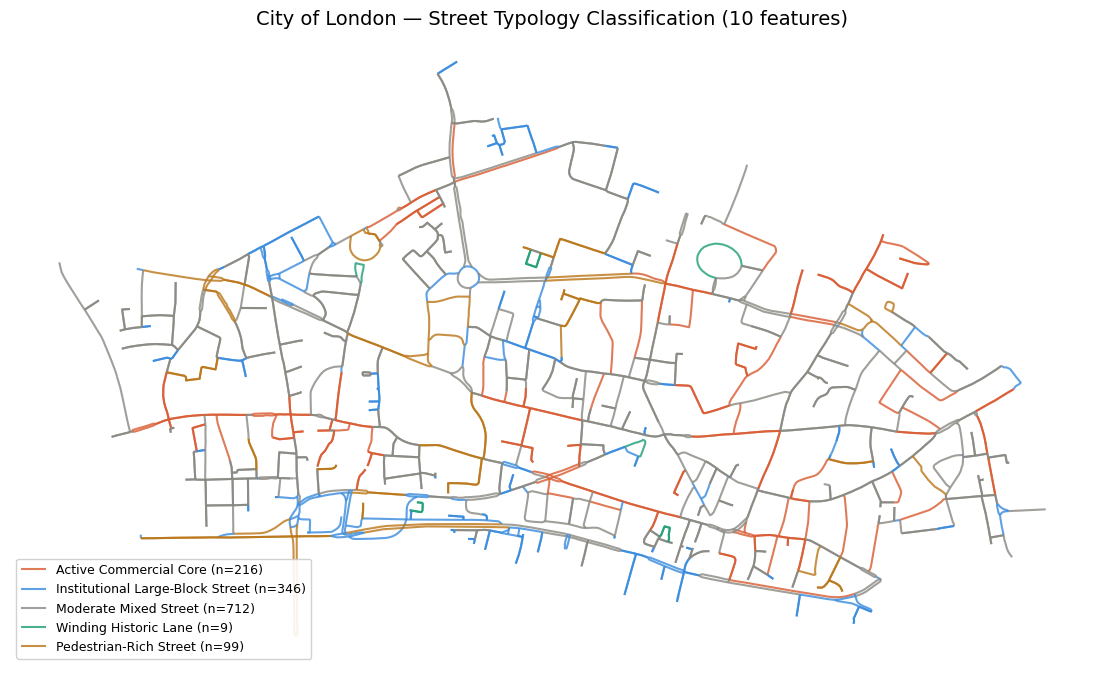

Improved typology map saved.


In [27]:
# Merge back to geometry
edges_typed_v2 = edges_proj.copy().reset_index()
features_v2_reset = features_v2.reset_index()
edges_typed_v2 = edges_typed_v2.merge(
    features_v2_reset[['u','v','key','typology']], 
    on=['u','v','key'], 
    how='left'
)

colour_map_v2 = {
    'Active Commercial Core': '#D85A30',
    'Institutional Large-Block Street': '#378ADD',
    'Moderate Mixed Street': '#888780',
    'Winding Historic Lane': '#1D9E75',
    'Pedestrian-Rich Street': '#BA7517'
}

fig, ax = plt.subplots(figsize=(14, 10))

for typology, colour in colour_map_v2.items():
    subset = edges_typed_v2[edges_typed_v2['typology'] == typology]
    subset.plot(ax=ax, color=colour, linewidth=1.5,
                label=f'{typology} (n={len(subset)})', alpha=0.8)

ax.set_title("City of London — Street Typology Classification (10 features)", 
             fontsize=14)
ax.set_axis_off()
ax.legend(loc='lower left', fontsize=9, framealpha=0.9)

plt.savefig("/home/jovyan/work/outputs/london_typology_v2.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Improved typology map saved.")

What your map is showing and why it is academically meaningful

Orange — Active Commercial Core (216) — traces the major commercial arteries through the heart of the City. You can clearly see it following what would be Cheapside, Cannon Street and the main east-west commercial spine. Exactly where you would expect high commercial activity.

Blue — Institutional Large-Block Street (346) — concentrated in clusters, particularly visible in the north and edges of the City. These are the areas around large financial institutions and corporate headquarters — streets flanked by enormous buildings with little street-level activity. The pattern is spatially coherent.

Grey — Moderate Mixed Street (712) — the background fabric of the City. Fills the spaces between the more distinctive types. This is the ordinary working city.

Green — Winding Historic Lane (9) — only 9 streets but look at them on the map. You can actually see the curves. These tiny green segments are medieval survivals — streets that have existed in roughly the same form for 800 years. That your algorithm found them automatically from sinuosity data alone is a genuinely interesting finding.

Gold — Pedestrian-Rich Street (99) — scattered but visible, often running alongside or between the commercial streets. These are the streets with deliberate pedestrian infrastructure — public realm investment visible in the data.

This map is your dissertation's headline figure
This is Figure 5.1 in your results chapter. The caption reads:
"Figure 5.1: Street typology classification of the City of London derived from K-means clustering (k=5) applied to 10 spatial features. Each colour represents a distinct typology identified through unsupervised machine learning. Data sourced from OpenStreetMap contributors (2024), accessed via osmnx (Boeing, 2017)."

In [28]:
# Save your complete feature table with typologies
final_save = features_v2.reset_index()
final_save.to_csv("/home/jovyan/work/data/london_final_features.csv", index=False)
print("Final feature table saved.")
print(f"Shape: {final_save.shape}")

Final feature table saved.
Shape: (1382, 15)
